In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('ggplot')

In [2]:
df = pd.read_csv("dataanalytics.csv")

In [3]:
df.head()

,OrderID,Date,CustomerID,Product,Quantity,UnitPrice,ShippingAddress,PaymentMethod,OrderStatus,TrackingNumber,ItemsInCart,CouponCode,ReferralSource,TotalPrice
0,ORD200000,2023-01-04,C72649,Monitor,5,570.62,928 Main St,Debit Card,Shipped,TRK37947903,7,SAVE10,Instagram,2853.10
1,ORD200001,2024-08-23,C75739,Phone,2,151.35,823 Main St,Online,Shipped,TRK91186779,3,SAVE10,Referral,302.70
2,ORD200002,2024-02-27,C81728,Tablet,5,550.68,512 Main St,Credit Card,Cancelled,TRK42903982,8,FREESHIP,Email,2753.40
3,ORD200003,2023-10-15,C33540,Chair,1,273.19,275 Main St,Debit Card,Returned,TRK62788070,5,SAVE10,Facebook,273.19
4,ORD200004,2025-05-08,C81840,Printer,4,626.01,668 Main St,Online,Delivered,TRK29241424,8,SAVE10,Email,2504.04


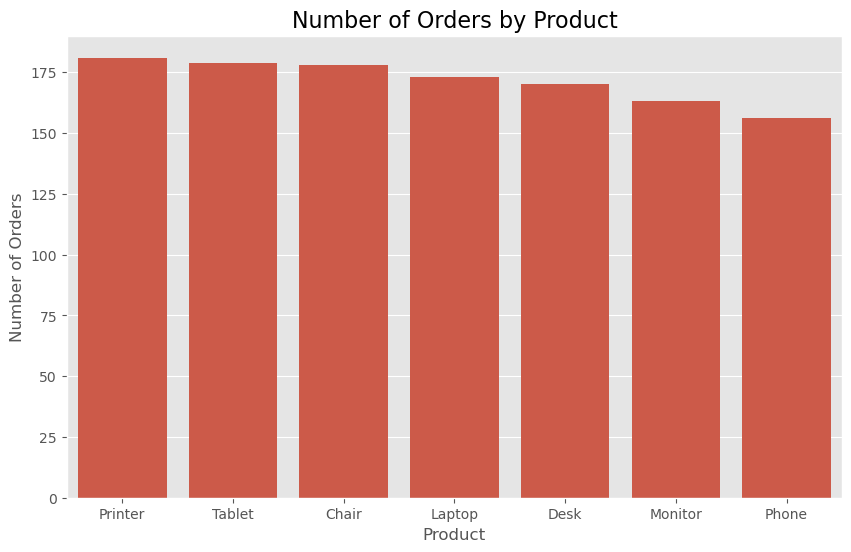

In [4]:
plt.figure(figsize=(10,6))

product_count = df['Product'].value_counts()

sns.barplot(
    x=product_count.index,
    y=product_count.values
)

plt.title("Number of Orders by Product", fontsize=16)
plt.xlabel("Product")
plt.ylabel("Number of Orders")

plt.show()

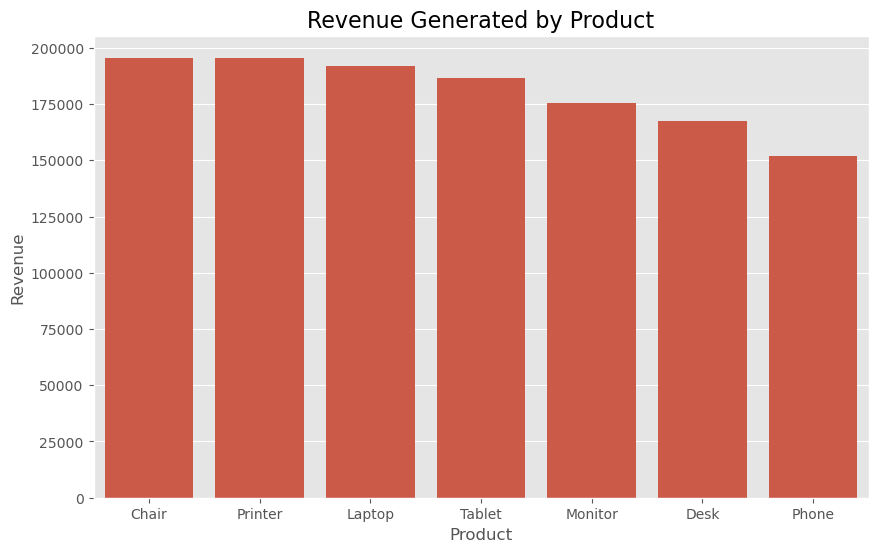

In [5]:
product_revenue = df.groupby('Product')['TotalPrice'].sum().sort_values(ascending=False)

plt.figure(figsize=(10,6))

sns.barplot(
    x=product_revenue.index,
    y=product_revenue.values
)

plt.title("Revenue Generated by Product", fontsize=16)
plt.xlabel("Product")
plt.ylabel("Revenue")

plt.show()

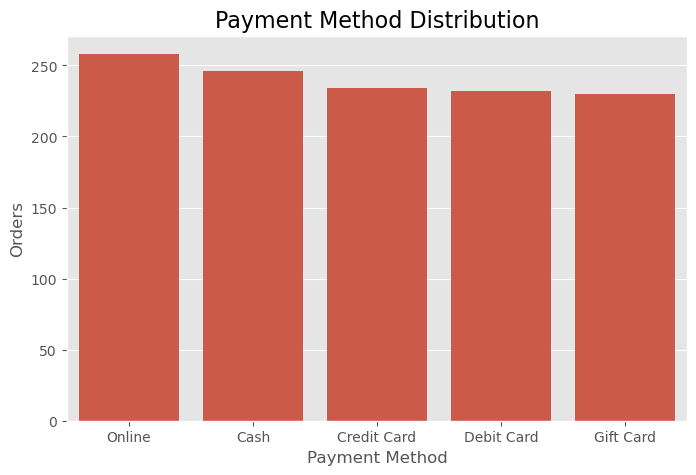

In [7]:
plt.figure(figsize=(8,5))

payment = df['PaymentMethod'].value_counts()

sns.barplot(
    x=payment.index,
    y=payment.values
)

plt.title("Payment Method Distribution", fontsize=16)
plt.xlabel("Payment Method")
plt.ylabel("Orders")

plt.show()

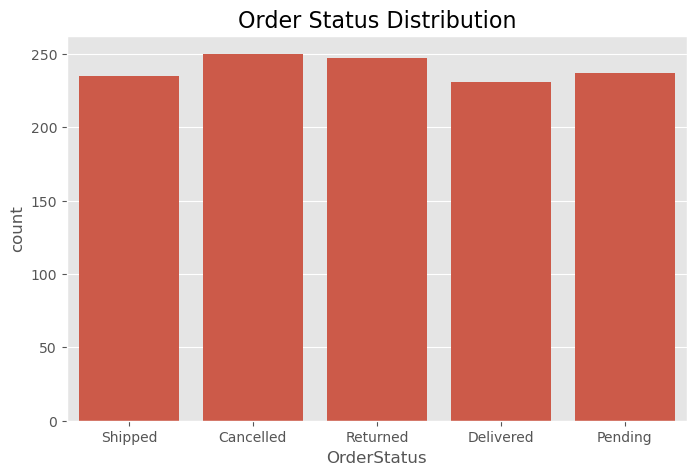

In [8]:
plt.figure(figsize=(8,5))

sns.countplot(
    x='OrderStatus',
    data=df
)

plt.title("Order Status Distribution", fontsize=16)

plt.show()

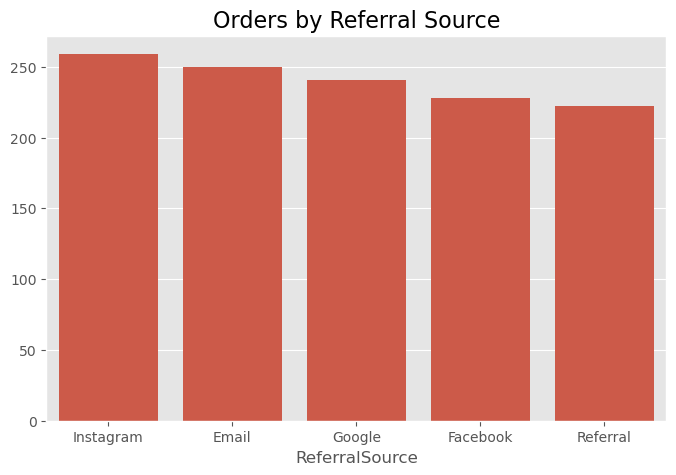

In [9]:
plt.figure(figsize=(8,5))

referral = df['ReferralSource'].value_counts()

sns.barplot(
    x=referral.index,
    y=referral.values
)

plt.title("Orders by Referral Source", fontsize=16)

plt.show()

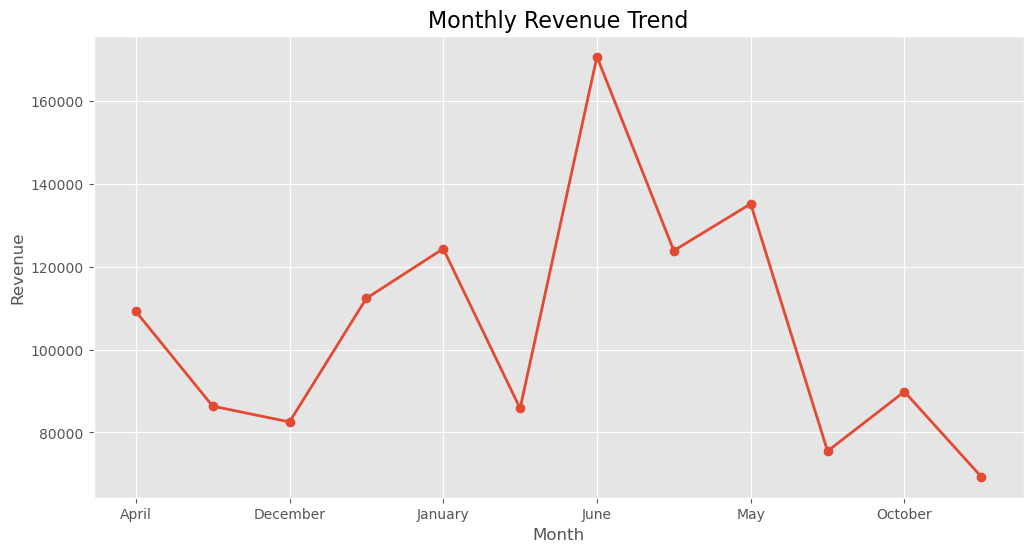

In [10]:
df['Date'] = pd.to_datetime(df['Date'])

df['Month'] = df['Date'].dt.month_name()

monthly_sales = df.groupby('Month')['TotalPrice'].sum()

plt.figure(figsize=(12,6))

monthly_sales.plot(
    marker='o',
    linewidth=2
)

plt.title("Monthly Revenue Trend", fontsize=16)
plt.xlabel("Month")
plt.ylabel("Revenue")

plt.show()

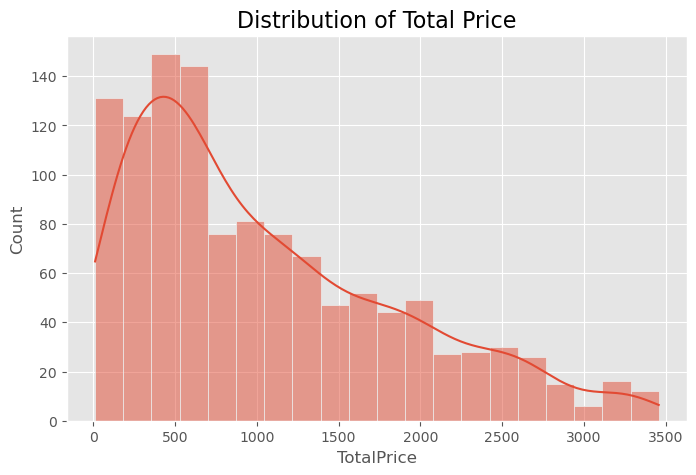

In [11]:
plt.figure(figsize=(8,5))

sns.histplot(
    df['TotalPrice'],
    bins=20,
    kde=True
)

plt.title("Distribution of Total Price", fontsize=16)

plt.show()

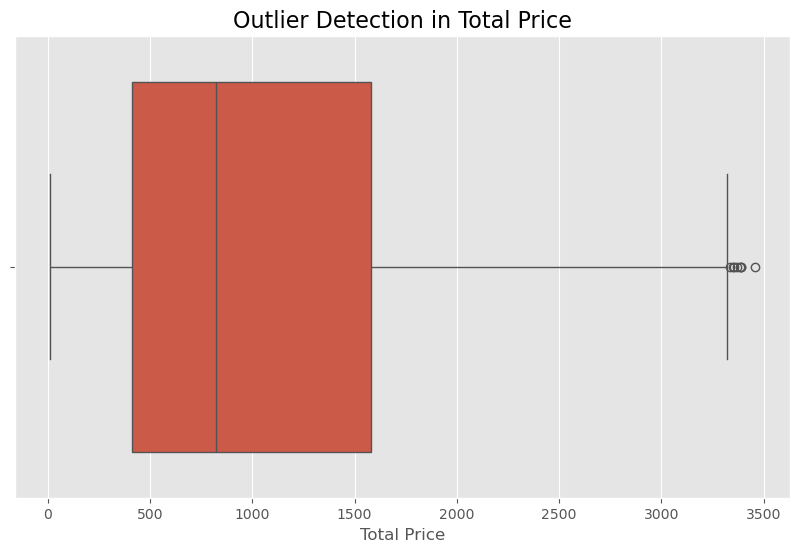

In [12]:
plt.figure(figsize=(10,6))

sns.boxplot(x=df['TotalPrice'])

plt.title("Outlier Detection in Total Price", fontsize=16)
plt.xlabel("Total Price")

plt.show()

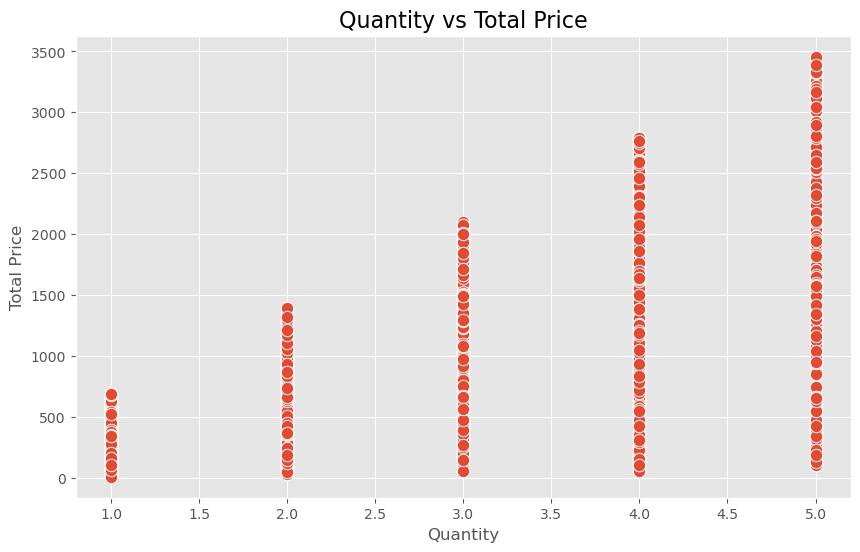

In [13]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    x='Quantity',
    y='TotalPrice',
    data=df,
    s=80
)

plt.title("Quantity vs Total Price", fontsize=16)
plt.xlabel("Quantity")
plt.ylabel("Total Price")

plt.show()

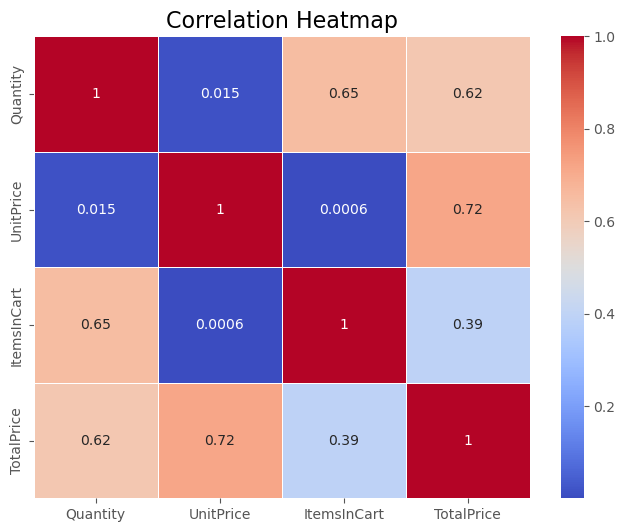

In [14]:
numeric_df = df[['Quantity', 'UnitPrice', 'ItemsInCart', 'TotalPrice']]

plt.figure(figsize=(8,6))

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap='coolwarm',
    linewidths=0.5
)

plt.title("Correlation Heatmap", fontsize=16)

plt.show()

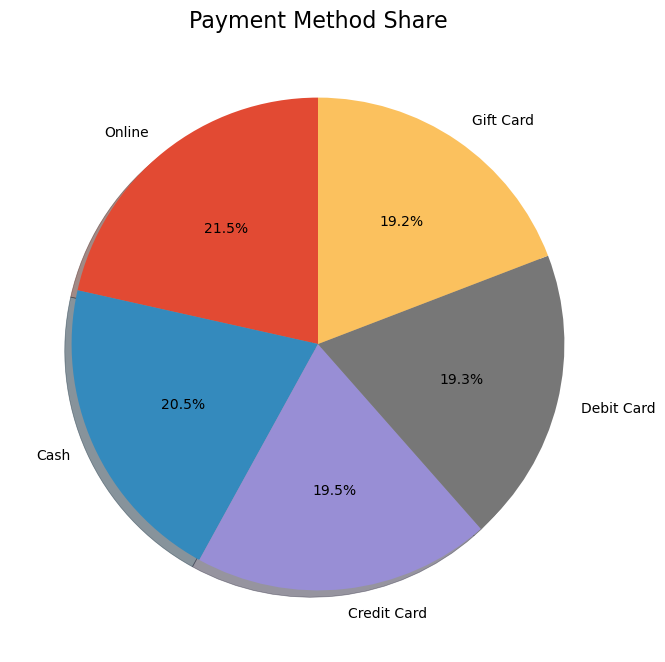

In [15]:
payment = df['PaymentMethod'].value_counts()

plt.figure(figsize=(8,8))

plt.pie(
    payment,
    labels=payment.index,
    autopct='%1.1f%%',
    startangle=90,
    shadow=True
)

plt.title("Payment Method Share", fontsize=16)

plt.show()

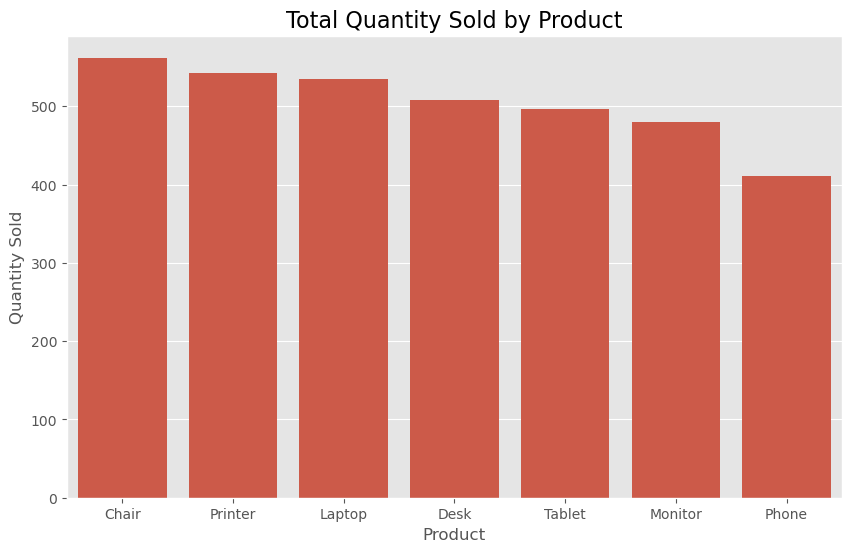

In [16]:
quantity = df.groupby('Product')['Quantity'].sum().sort_values(ascending=False)

plt.figure(figsize=(10,6))

sns.barplot(
    x=quantity.index,
    y=quantity.values
)

plt.title("Total Quantity Sold by Product", fontsize=16)
plt.xlabel("Product")
plt.ylabel("Quantity Sold")

plt.show()

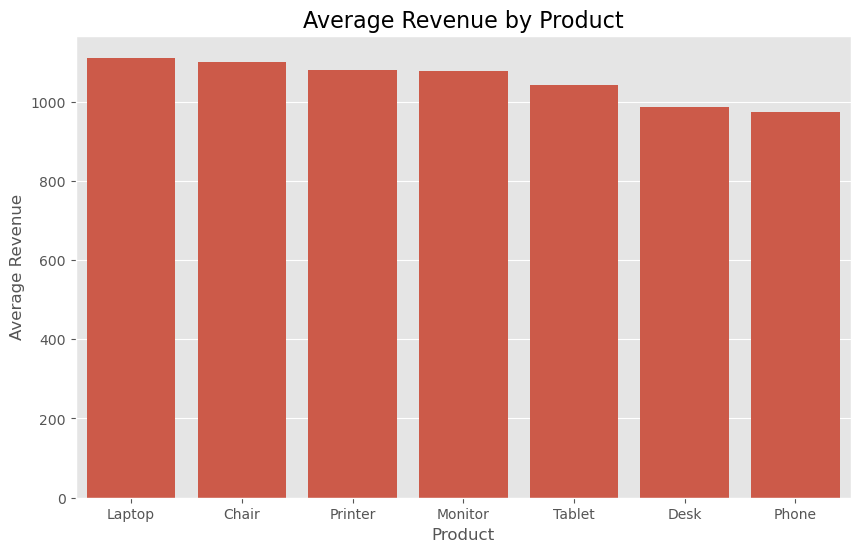

In [17]:
average_sales = df.groupby('Product')['TotalPrice'].mean().sort_values(ascending=False)

plt.figure(figsize=(10,6))

sns.barplot(
    x=average_sales.index,
    y=average_sales.values
)

plt.title("Average Revenue by Product", fontsize=16)
plt.xlabel("Product")
plt.ylabel("Average Revenue")

plt.show()

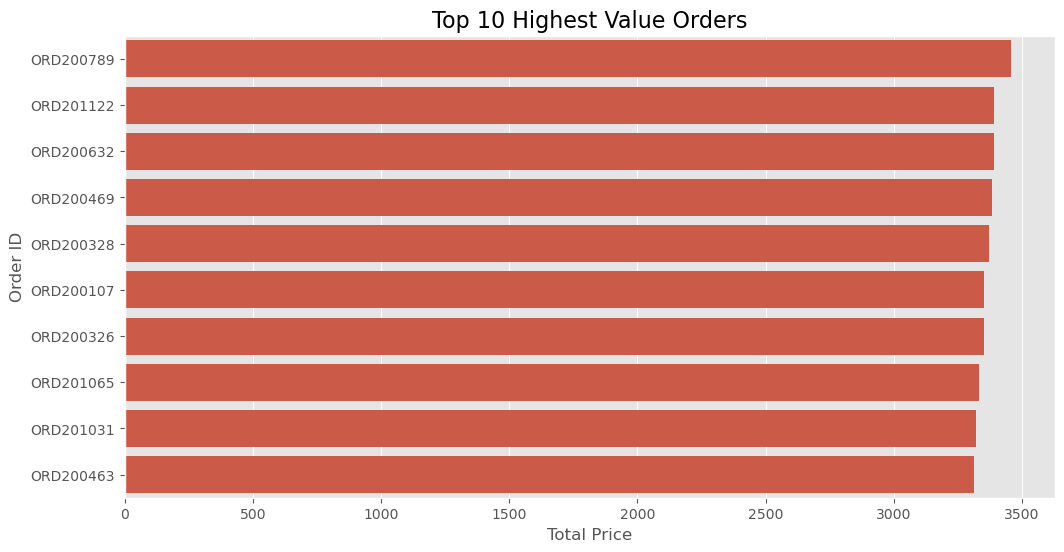

In [18]:
top_orders = df.nlargest(10, 'TotalPrice')

plt.figure(figsize=(12,6))

sns.barplot(
    x='TotalPrice',
    y='OrderID',
    data=top_orders
)

plt.title("Top 10 Highest Value Orders", fontsize=16)
plt.xlabel("Total Price")
plt.ylabel("Order ID")

plt.show()

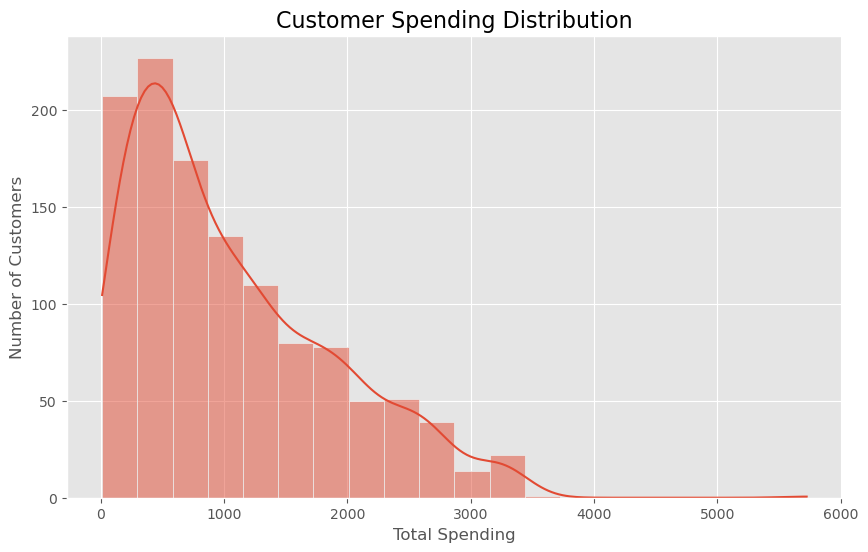

In [19]:
customer_spending = df.groupby('CustomerID')['TotalPrice'].sum()

plt.figure(figsize=(10,6))

sns.histplot(
    customer_spending,
    bins=20,
    kde=True
)

plt.title("Customer Spending Distribution", fontsize=16)
plt.xlabel("Total Spending")
plt.ylabel("Number of Customers")

plt.show()

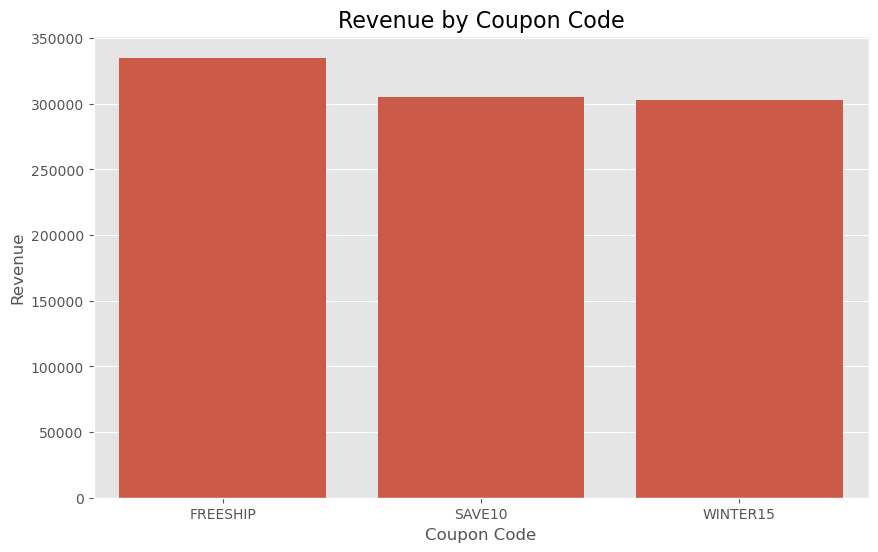

In [20]:
coupon_revenue = df.groupby('CouponCode')['TotalPrice'].sum().sort_values(ascending=False)

plt.figure(figsize=(10,6))

sns.barplot(
    x=coupon_revenue.index,
    y=coupon_revenue.values
)

plt.title("Revenue by Coupon Code", fontsize=16)
plt.xlabel("Coupon Code")
plt.ylabel("Revenue")

plt.show()

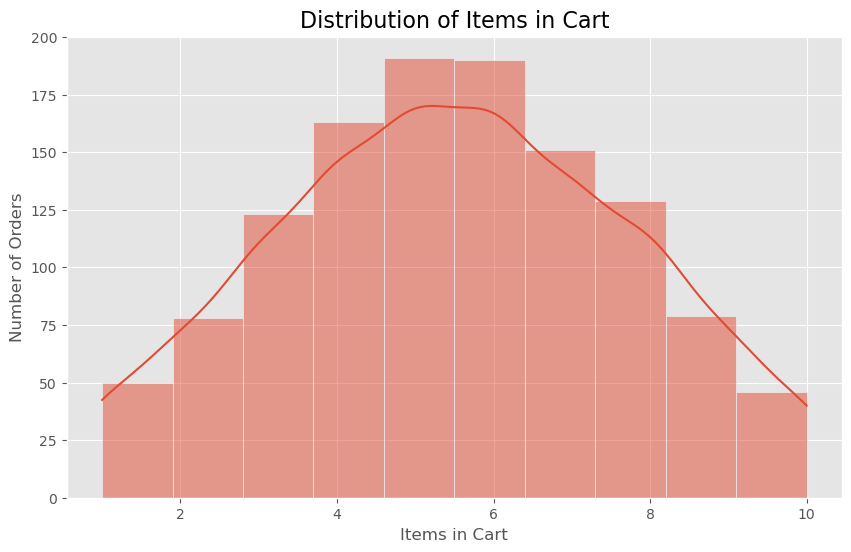

In [21]:
plt.figure(figsize=(10,6))

sns.histplot(
    df['ItemsInCart'],
    bins=10,
    kde=True
)

plt.title("Distribution of Items in Cart", fontsize=16)
plt.xlabel("Items in Cart")
plt.ylabel("Number of Orders")

plt.show()

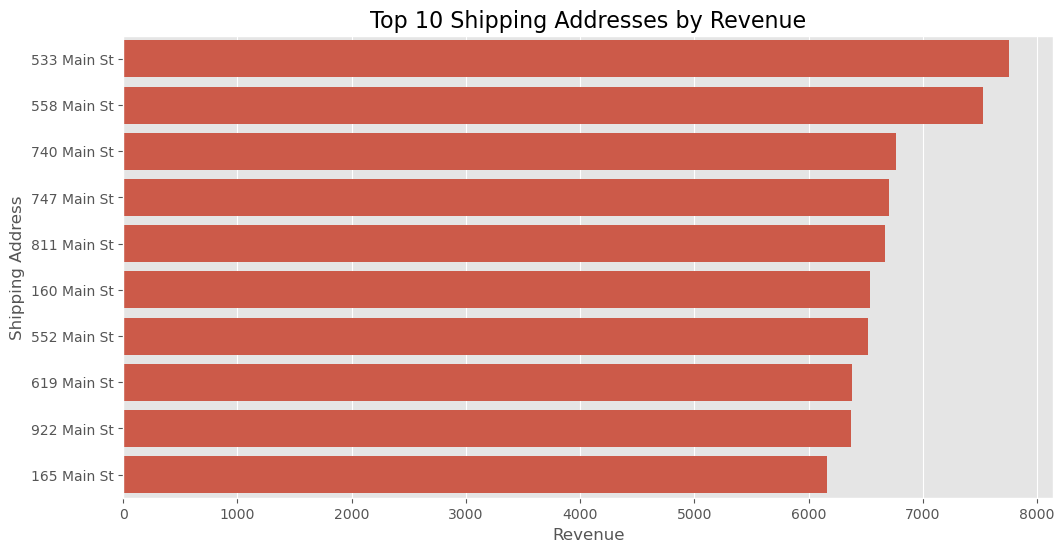

In [22]:
address_revenue = (
    df.groupby('ShippingAddress')['TotalPrice']
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

plt.figure(figsize=(12,6))

sns.barplot(
    x=address_revenue.values,
    y=address_revenue.index
)

plt.title("Top 10 Shipping Addresses by Revenue", fontsize=16)
plt.xlabel("Revenue")
plt.ylabel("Shipping Address")

plt.show()

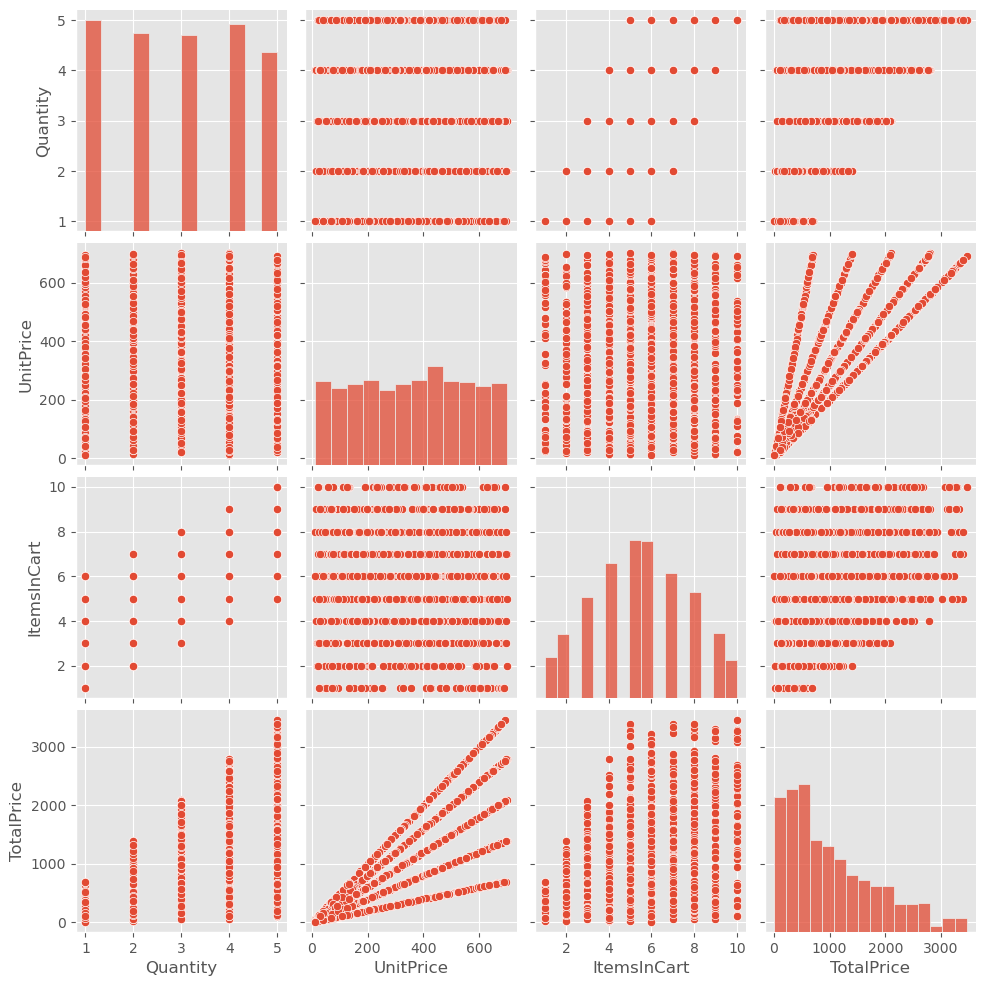

In [23]:
numeric_data = df[['Quantity','UnitPrice','ItemsInCart','TotalPrice']]

sns.pairplot(numeric_data)

plt.show()

In [24]:
print("="*50)
print("E-COMMERCE SALES DASHBOARD")
print("="*50)

print(f"Total Orders        : {len(df)}")
print(f"Total Revenue       : ₹{df['TotalPrice'].sum():,.2f}")
print(f"Average Order Value : ₹{df['TotalPrice'].mean():,.2f}")
print(f"Highest Order Value : ₹{df['TotalPrice'].max():,.2f}")
print(f"Lowest Order Value  : ₹{df['TotalPrice'].min():,.2f}")
print(f"Unique Customers    : {df['CustomerID'].nunique()}")

print("="*50)

E-COMMERCE SALES DASHBOARD
Total Orders        : 1200
Total Revenue       : ₹1,264,761.96
Average Order Value : ₹1,053.97
Highest Order Value : ₹3,456.40
Lowest Order Value  : ₹11.39
Unique Customers    : 1189
